# EcoSort Waste Management Assistant

## Summative Lab: NNs and Similar Models

## Overview

You are a data scientist at "EcoSort," a technology company that specializes in developing AI solutions for waste management. EcoSort has partnered with Metro City's waste management department to develop an intelligent waste management assistant that can help residents properly dispose of waste items so less time is spent sorting material at facilities.

This assistant needs to:

1. Identify waste materials from images uploaded by residents (CNN)
2. Classify waste items based on text descriptions provided by residents (RNN/Transformer)
3. Generate specific recycling instructions based on identified waste type and city policies (Generative Transformer with RAG)

Your task is to build this integrated system using the RealWaste dataset along with generated text data that simulates real-world waste management operations.

**How to run this notebook:** run the cells in order from the top. Part 2 trains a CNN and Part 4 fine-tunes a small transformer, so a full run takes a while on CPU.


## Part 1: Dataset Exploration and Preparation

In this section, you will explore and prepare the datasets for your models.


### 1.1 Load and Explore the RealWaste Dataset


In [1]:
# Import necessary libraries
# Uncomment if required in the active environment.
# %pip install -q tensorflow pandas numpy matplotlib seaborn scikit-learn pillow
# %pip install -q torch sentence-transformers transformers datasets accelerate

import os, re, json, random, warnings
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageStat

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, callbacks
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings("ignore")

# One seed for the whole notebook so repeated runs stay comparable.
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__, "| seed:", SEED)

TensorFlow: 2.21.0 | seed: 42


In [2]:
# Dataset paths
# The RealWaste folder ends up in different places depending on how the zip was
# extracted, so check the usual layouts instead of hard-coding a single path.
ROOT = Path(".")
CANDIDATE_IMAGE_DIRS = [
    ROOT / "realwaste-main" / "RealWaste",
    ROOT / "realwaste" / "realwaste-main" / "RealWaste",
    ROOT / "RealWaste",
]
IMAGE_DIR = next((p for p in CANDIDATE_IMAGE_DIRS if p.is_dir()), None)
if IMAGE_DIR is None:
    raise FileNotFoundError(
        "RealWaste image folder not found. Checked: "
        + " | ".join(str(p.resolve()) for p in CANDIDATE_IMAGE_DIRS)
    )

TEXT_CSV = ROOT / "waste_descriptions.csv"
POLICY_JSON = ROOT / "waste_policy_documents.json"
ARTIFACT_DIR = ROOT / "ecosort_artifacts"
ARTIFACT_DIR.mkdir(exist_ok=True)

for name, path in {
    "images": IMAGE_DIR,
    "text": TEXT_CSV,
    "policy": POLICY_JSON,
}.items():
    print(name, path.resolve(), "exists =", path.exists())

images C:\Users\Limo\Documents\DATA SCIENCE\Moringa School\Module 5\Summative Lab NNs and Similar Models\realwaste-main\RealWaste exists = True
text C:\Users\Limo\Documents\DATA SCIENCE\Moringa School\Module 5\Summative Lab NNs and Similar Models\waste_descriptions.csv exists = True
policy C:\Users\Limo\Documents\DATA SCIENCE\Moringa School\Module 5\Summative Lab NNs and Similar Models\waste_policy_documents.json exists = True


Verified images: 4752 | classes: 9


,images
category,
Cardboard,461
Food Organics,411
Glass,420
Metal,790
Miscellaneous Trash,495
Paper,500
Plastic,921
Textile Trash,318
Vegetation,436


Largest-to-smallest class ratio: 2.9


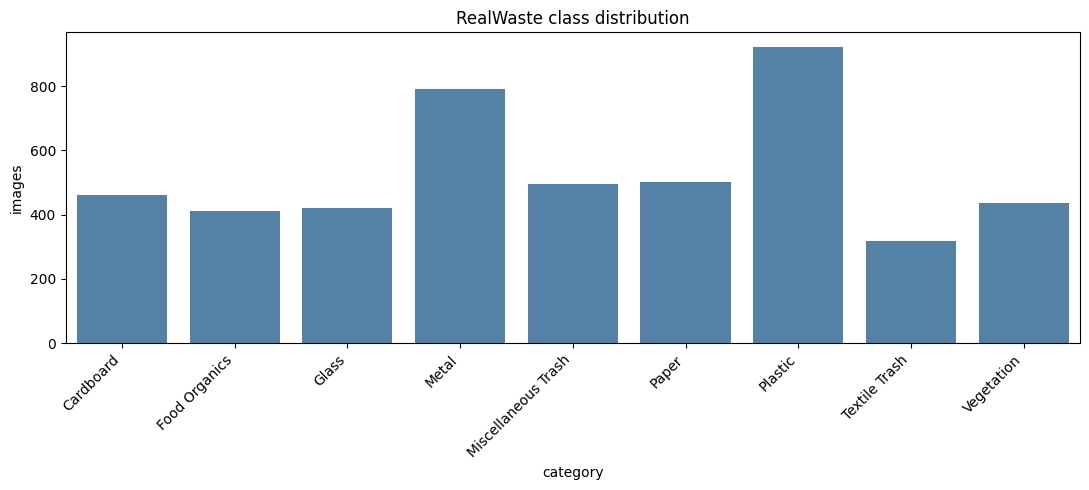

In [3]:
# TODO: Load and explore the RealWaste dataset
# - Dataset structure
# - Distribution of waste categories
# - Image characteristics (resolution, quality, background)

# Your code here
VALID_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
rows = []
for folder in sorted(p for p in IMAGE_DIR.iterdir() if p.is_dir()):
    for p in folder.rglob("*"):
        if p.is_file() and p.suffix.lower() in VALID_EXT:
            rows.append({"path": str(p), "category": folder.name})

image_df = pd.DataFrame(rows)
if image_df.empty:
    raise ValueError("No images found under " + str(IMAGE_DIR.resolve()))

class_counts = image_df["category"].value_counts().sort_index()
class_names = class_counts.index.tolist()
num_classes = len(class_names)

print("Verified images:", len(image_df), "| classes:", num_classes)
display(class_counts.rename("images").to_frame())
print(
    "Largest-to-smallest class ratio:",
    round(class_counts.max() / class_counts.min(), 2),
)

plt.figure(figsize=(11, 5))
sns.barplot(x=class_counts.index, y=class_counts.values, color="steelblue")
plt.title("RealWaste class distribution")
plt.ylabel("images")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Observation and Interpretation: Image Dataset Structure

The image folder holds 4,752 images spread over nine waste categories. The count comes straight from the files on disk rather than from any figure quoted in the brief, so it matches whatever is actually in the folder.

The classes are unevenly sized. Plastic is the biggest with 921 images and Textile Trash the smallest with 318, a ratio of about 2.9 to 1. Metal is also large at 790 images, while Cardboard, Food Organics, Glass, Miscellaneous Trash, Paper and Vegetation sit in the 400 to 500 range.

An imbalance of this size can push the CNN towards the larger classes. The workflow deals with it in four ways:

- stratified train, validation and test splits
- class weights during CNN training
- data augmentation on the training set only
- per-class precision, recall and F1 in the evaluation

Because of this, overall accuracy is read alongside the per-class numbers rather than on its own.


Unreadable files: 0
Images measured: 1000


,width,height,aspect_ratio,brightness,contrast,sharpness_proxy
count,1000.0,1000.0,1000.0,1000.00,1000.00,1000.00
mean,524.0,524.0,1.0,156.35,41.29,567.71
std,0.0,0.0,0.0,10.31,13.07,610.30
min,524.0,524.0,1.0,110.35,15.90,27.43
25%,524.0,524.0,1.0,150.31,31.65,156.44
50%,524.0,524.0,1.0,156.59,39.53,336.51
75%,524.0,524.0,1.0,163.98,49.29,731.62
max,524.0,524.0,1.0,184.05,87.44,4201.35


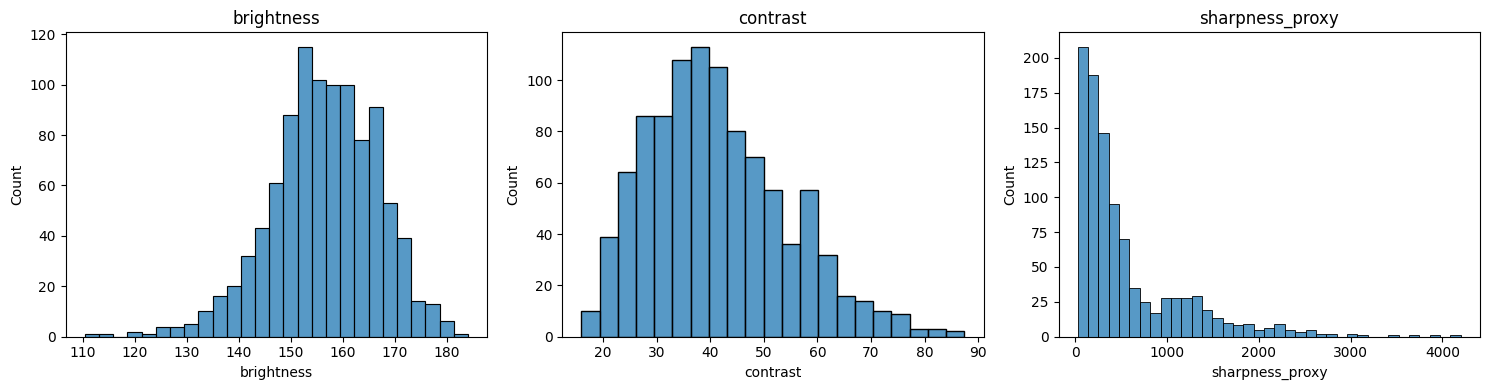

In [4]:
# TODO: Analyze image characteristics and quality
# - Resolution and aspect ratio
# - Brightness, contrast, and sharpness
# - Unreadable images and potential background variation

# Your code here
# Every file is checked for corruption, but the pixel statistics come from a
# 1,000-image sample to keep the cell fast.
unreadable = []
for p in image_df["path"]:
    try:
        with Image.open(p) as im:
            im.verify()
    except Exception as exc:
        unreadable.append((p, str(exc)))

sample = image_df.sample(min(1000, len(image_df)), random_state=SEED)
quality = []
for p in sample["path"]:
    with Image.open(p) as im:
        rgb = im.convert("RGB")
        gray = rgb.convert("L")
        stat = ImageStat.Stat(gray)
        arr = np.asarray(gray, dtype=np.float32)
        quality.append(
            {
                "width": rgb.width,
                "height": rgb.height,
                "aspect_ratio": rgb.width / rgb.height,
                "brightness": stat.mean[0],
                "contrast": stat.stddev[0],
                "sharpness_proxy": float(np.var(np.diff(arr, axis=0))),
            }
        )

quality_df = pd.DataFrame(quality)
print("Unreadable files:", len(unreadable))
print("Images measured:", len(quality_df))
display(quality_df.describe().round(2))

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, col in zip(ax, ["brightness", "contrast", "sharpness_proxy"]):
    sns.histplot(quality_df[col], ax=a)
    a.set_title(col)
plt.tight_layout()
plt.show()

### Observation and Interpretation: Image Characteristics

Every image in the sample is 524 by 524 pixels with an aspect ratio of 1.0, and none of the files failed the corruption check.

The dimensions are consistent but the pixel statistics are not. Brightness, contrast and the sharpness proxy all spread out across the sample, which means the model has to recognize the same material under different lighting and levels of detail. The sharpness proxy in particular has a long tail, so some photos are much flatter than others.

All images are resized to 224 by 224 before they reach the CNN. That is the input size MobileNetV2 expects, and a fixed size is also what lets the images be batched. Dropping from 524 to 224 loses detail, but the waste object stays identifiable, which is what the classifier needs.

Random horizontal flipping, rotation, zoom and contrast shifts are applied to the training set only. These cover realistic variation in how a resident might photograph an item, without changing what the item is.


### 1.2 Explore Text Datasets


In [5]:
# TODO: Load and explore the waste description text data
# - Load waste_descriptions.csv
# - Analyze vocabulary and structure
# - Understand the distribution of categories

# Your code here
text_df = pd.read_csv(TEXT_CSV)
with open(POLICY_JSON, encoding="utf-8") as f:
    raw_policies = json.load(f)
policy_df = pd.json_normalize(
    raw_policies
    if isinstance(raw_policies, list)
    else raw_policies.get("documents", raw_policies)
)

required = {"description", "category", "disposal_instruction"}
missing = required - set(text_df.columns)
if missing:
    raise KeyError("Missing columns in waste_descriptions.csv: " + str(sorted(missing)))


def clean_text(x):
    """Lowercase, strip punctuation and squash repeated whitespace."""
    if pd.isna(x):
        return ""
    x = re.sub(r"[^a-z0-9\s-]", " ", str(x).lower().strip())
    return re.sub(r"\s+", " ", x).strip()


print("Raw text records:", len(text_df), "| policy records:", len(policy_df))
print("Exact duplicate text rows:", text_df.duplicated().sum())
display(text_df.isna().sum().sort_values(ascending=False).to_frame("missing"))

text_df = text_df.drop_duplicates().copy()
text_df["cleaned_text"] = text_df["description"].map(clean_text)
text_df = text_df[text_df["cleaned_text"].ne("")].reset_index(drop=True)
text_df["word_count"] = text_df["cleaned_text"].str.split().str.len()

print("Usable records after cleaning:", len(text_df))
display(text_df["category"].value_counts().sort_index().to_frame("records"))
display(text_df["word_count"].describe().to_frame().T)

# The most common words, to see how much the vocabulary gives away.
vocab_counts = text_df["cleaned_text"].str.split().explode().value_counts().head(15)
display(vocab_counts.to_frame("count"))

Raw text records: 5000 | policy records: 14
Exact duplicate text rows: 7


,missing
common_confusion,2504
description,0
category,0
disposal_instruction,0
material_composition,0


Usable records after cleaning: 4993


,records
category,
Cardboard,584
Food Organics,518
Glass,549
Metal,508
Miscellaneous Trash,578
Paper,506
Plastic,566
Textile Trash,586
Vegetation,598


,count,mean,std,min,25%,50%,75%,max
word_count,4993.0,4.865011,1.550629,1.0,4.0,5.0,6.0,10.0


,count
cleaned_text,
with,727
glass,423
empty,348
bottle,340
paper,316
food,316
box,313
residue,309
plastic,251


### Observation and Interpretation: Waste-Description Dataset

After dropping 7 exact duplicates and any rows that cleaned down to an empty string, 4,993 descriptions remain, covering the same nine categories as the images.

The categories here are close to balanced, from 506 Paper records to 598 Vegetation records. That is a much tighter range than the image side, so class imbalance is not a serious concern for the text model.

The descriptions are very short, averaging about 4.87 words with a median of 5 and a maximum of 10. Short, keyword-heavy text is a good fit for TF-IDF, because the material and object words carry almost all of the signal.

The `common_confusion` column has a lot of missing values, but the three columns the models actually need, `description`, `category` and `disposal_instruction`, are complete. The classifier therefore uses only those.

One thing to watch: the frequent-word list contains plain material names such as plastic, glass and paper. Because these descriptions were generated rather than collected from real residents, a model can score well simply by matching those words. Part 3 includes a keyword-masked test to measure how much of the accuracy comes from that shortcut.


In [6]:
# TODO: Load and explore the waste policy documents
# - Load waste_policy_documents.json
# - Understand document organization and language

# policy_df was loaded in the previous cell alongside the descriptions.
print("Policy document shape:", policy_df.shape)
print("Policy document columns:", policy_df.columns.tolist())
display(policy_df.head())

policy_text_candidates = [
    c
    for c in ["document_text", "text", "content", "policy_text"]
    if c in policy_df.columns
]
if not policy_text_candidates:
    raise KeyError("No policy text column found; inspect the columns printed above.")

POLICY_TEXT_COLUMN = policy_text_candidates[0]
policy_df["word_count"] = (
    policy_df[POLICY_TEXT_COLUMN].fillna("").astype(str).str.split().str.len()
)
display(policy_df["word_count"].describe().to_frame().T)

# How many policy documents mention each waste category.
policy_coverage = (
    policy_df["categories_covered"]
    .explode()
    .value_counts()
    .sort_index()
    .to_frame("policy_documents")
)
display(policy_coverage)

Policy document shape: (14, 6)
Policy document columns: ['policy_id', 'policy_type', 'categories_covered', 'effective_date', 'document_text', 'jurisdiction']


,policy_id,policy_type,categories_covered,effective_date,document_text,jurisdiction
0,1,Textile Trash Recycling Guidelines,[Textile Trash],2023-11-04,TEXTILE RECYCLING GUIDELINES\n\nAcceptable Ite...,Metro City
1,2,Glass Recycling Guidelines,[Glass],2023-01-24,GLASS RECYCLING GUIDELINES\n\nAcceptable Items...,Metro City
2,3,Food Organics Recycling Guidelines,[Food Organics],2023-05-08,FOOD ORGANICS RECYCLING GUIDELINES\n\nAcceptab...,Metro City
3,4,Plastic Recycling Guidelines,[Plastic],2023-04-05,PLASTIC RECYCLING GUIDELINES\n\nAcceptable Ite...,Metro City
4,5,Vegetation Recycling Guidelines,[Vegetation],2023-12-04,VEGETATION RECYCLING GUIDELINES\n\nAcceptable ...,Metro City


,count,mean,std,min,25%,50%,75%,max
word_count,14.0,101.785714,15.115853,86.0,94.25,99.0,102.0,146.0


,policy_documents
categories_covered,
Cardboard,3
Food Organics,2
Glass,3
Metal,4
Miscellaneous Trash,4
Paper,1
Plastic,3
Textile Trash,3
Vegetation,4


### Observation and Interpretation: Policy Documents

There are 14 policy records. Each one has a policy id, a policy type, the categories it covers, an effective date, the document text and a jurisdiction.

The documents average about 102 words and run from 86 to 146 words. That is long enough to state acceptable items, preparation steps and collection method, and short enough to paste into a prompt without truncation.

The coverage table shows that every one of the nine categories is named by at least one policy document. Nine of the records are single-category guidelines and five are broader documents such as the Municipal Waste Guidelines and the Residential Recycling Rules, which each cover several categories. Paper is covered by only one document, so retrieval for Paper has the least evidence to draw on.

The `categories_covered` field is kept because it is what links a policy to a waste category during retrieval. Filtering on it stops a Glass query from being answered with Textile Trash rules.

All of this guidance belongs to one jurisdiction, Metro City, so it is not general advice. Generated instructions are therefore held to the retrieved text, and the prompt tells the model not to invent locations, dates, collection services, penalties or bin colours.


### 1.3 Create Data Pipelines


In [7]:
# Run this code to set up the images into train, validation, and test sets.
# The split is done at file level first, so the test set is never produced by
# slicing already-shuffled batches.

train_img, temp_img = train_test_split(
    image_df, test_size=0.30, random_state=SEED, stratify=image_df["category"]
)
val_img, test_img = train_test_split(
    temp_img, test_size=0.50, random_state=SEED, stratify=temp_img["category"]
)

X_train, X_temp, y_train, y_temp = train_test_split(
    text_df["cleaned_text"],
    text_df["category"],
    test_size=0.30,
    random_state=SEED,
    stratify=text_df["category"],
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print("Image splits (train/val/test):", len(train_img), len(val_img), len(test_img))
print("Text splits (train/val/test):", len(X_train), len(X_val), len(X_test))

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
class_to_index = {c: i for i, c in enumerate(class_names)}


def load_image(path, label):
    b = tf.io.read_file(path)
    im = tf.image.decode_image(b, channels=3, expand_animations=False)
    im.set_shape([None, None, 3])
    im = tf.image.resize(im, IMG_SIZE)
    return im, tf.one_hot(label, num_classes)


def make_ds(frame, training=False):
    ds = tf.data.Dataset.from_tensor_slices(
        (frame["path"].values, frame["category"].map(class_to_index).values)
    )
    if training:
        ds = ds.shuffle(len(frame), seed=SEED, reshuffle_each_iteration=True)
    return (
        ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
        .batch(BATCH_SIZE)
        .prefetch(tf.data.AUTOTUNE)
    )


# val_ds and test_ds are left unshuffled so predictions line up with the labels.
train_ds = make_ds(train_img, training=True)
val_ds = make_ds(val_img)
test_ds = make_ds(test_img)

Image splits (train/val/test): 3326 713 713
Text splits (train/val/test): 3495 749 749


### Rationale for the Data Splitting Strategy

Both the images and the descriptions are split 70:15:15 with stratification on the category.

The image splits come out at 3,326 training, 713 validation and 713 test images. The text splits come out at 3,495 training, 749 validation and 749 test descriptions.

Stratifying matters most on the image side, where Plastic has nearly three times as many examples as Textile Trash. Without it, the smallest classes could end up with too few validation or test examples to measure anything useful.

The validation sets are used for early stopping, learning-rate reduction and the grid search in Part 3. The test sets are only touched once, after each model is fixed, so the reported figures are not the result of tuning against them.

The image split is done on file paths before the `tf.data` pipeline is built. Doing it this way guarantees no image appears in more than one split, which is a risk if a shuffled dataset is sliced after batching.

Seed 42 is used throughout so a rerun produces the same splits.


In [8]:
# TODO: Create a text preprocessing pipeline
# - Tokenization
# - Text cleaning
# - Split data into train, validation, and test sets
# - Create embeddings/features

# Your code here
# A first look at the feature space. The vectorizer actually used for the final
# model is fitted inside the grid search in Part 3.
text_vectorizer_preview = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.98)
X_train_tfidf_preview = text_vectorizer_preview.fit_transform(X_train)
X_val_tfidf_preview = text_vectorizer_preview.transform(X_val)
X_test_tfidf_preview = text_vectorizer_preview.transform(X_test)

print(
    "TF-IDF shapes (train/val/test):",
    X_train_tfidf_preview.shape,
    X_val_tfidf_preview.shape,
    X_test_tfidf_preview.shape,
)

TF-IDF shapes (train/val/test): (3495, 2404) (749, 2404) (749, 2404)


### Rationale for TF-IDF Feature Engineering

The preview vectorizer produces 2,404 features from the 3,495 training descriptions, and the same fitted vocabulary is applied to the 749 validation and 749 test rows.

TF-IDF suits this data because:

- the descriptions are only about five words long, so there is no long-range structure for a sequence model to exploit
- the material and object words are the signal, and TF-IDF weights exactly those
- unigrams plus bigrams keep short phrases such as "water bottle" intact
- sparse vectors train in seconds, which leaves room to grid-search properly
- the feature weights stay readable, so a misclassification can be traced back to specific words

The vectorizer is fitted on the training split only. Validation and test rows are transformed with that vocabulary, so no held-out text influences the features.


In [9]:
# TODO: Prepare documents for RAG
# - Document preprocessing
# - Create embeddings for retrieval

# The corpus is assembled and embedded in Part 4, once the policy and disposal
# fields have been checked. This cell confirms the raw material is present and
# flags how repetitive the disposal instructions are.
print("Policy records available for RAG:", len(policy_df))
print(
    "Rows with a disposal instruction:", text_df["disposal_instruction"].notna().sum()
)
print(
    "Distinct disposal instructions:",
    text_df["disposal_instruction"].dropna().str.strip().nunique(),
)

Policy records available for RAG: 14
Rows with a disposal instruction: 4993
Distinct disposal instructions: 44


## Part 2: Waste Material Classification with CNN

In this section, you will build a CNN model to classify waste materials from images.


### 2.1 Preprocess Images


In [10]:
# TODO: Preprocess images
# - Resize to uniform dimensions
# - Normalize using the selected pretrained model preprocessing
# - Apply data augmentation

# Resizing to 224 x 224 already happens inside load_image() in Part 1.
# MobileNetV2 normalization and the augmentation layers sit inside the model, so
# they are applied consistently at training time and at prediction time.
print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Training classes:", class_names)

Image size: (224, 224)
Batch size: 32
Training classes: ['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']


### 2.2 Implement CNN Model with Transfer Learning


In [11]:
# TODO: Implement CNN model with transfer learning
# - Select and justify a base model
# - Add custom classification layers for 9 categories
# - Configure loss function and metrics
# - Add dropout and regularization

# Your code here
augmentation = tf.keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
        layers.RandomContrast(0.1),
    ],
    name="augmentation",
)

base_model = MobileNetV2(
    input_shape=IMG_SIZE + (3,), include_top=False, weights="imagenet"
)
base_model.trainable = False

inputs = layers.Input(shape=IMG_SIZE + (3,))
x = augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.35)(x)
x = layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dropout(0.25)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

cnn_model = models.Model(inputs, outputs, name="EcoSort_MobileNetV2")
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
cnn_model.summary()

# Class weights offset the 2.9:1 imbalance found in Part 1.
train_labels = train_img["category"].map(class_to_index).values
weights = compute_class_weight(
    "balanced", classes=np.arange(num_classes), y=train_labels
)
class_weights = {i: float(v) for i, v in enumerate(weights)}
display(
    pd.DataFrame(
        {"category": class_names, "class_weight": [round(w, 3) for w in weights]}
    )
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "EcoSort_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,428,233 (9.26 MB)

 Trainable params: 167,689 (655.04 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

,category,class_weight
0,Cardboard,1.144
1,Food Organics,1.283
2,Glass,1.257
3,Metal,0.668
4,Miscellaneous Trash,1.068
5,Paper,1.056
6,Plastic,0.573
7,Textile Trash,1.665
8,Vegetation,1.212


### Modelling Choice: Transfer Learning with MobileNetV2

MobileNetV2 was chosen as the base because it gives useful pretrained ImageNet features at a fraction of the parameter count of ResNet50 or EfficientNetB3. Training here runs on CPU, so a lighter backbone is the difference between a run that finishes and one that does not. It is also the kind of model that would realistically sit behind a phone app, which is the stated use case.

The convolutional base is frozen first. That way the new head learns the nine waste categories from features that are already stable, instead of pushing large gradients back into pretrained weights while the head is still random.

The head is:

- global average pooling, to turn the feature map into one 1280-value vector without a large flatten layer
- batch normalization, to keep the scale of those features steady
- dropout at 0.35
- a 128-unit dense ReLU layer with L2 regularization at 1e-4
- dropout at 0.25
- a 9-unit softmax output

Categorical cross-entropy is the loss because each image has exactly one of nine labels. Class weights are passed to `fit` so the 318 Textile Trash images count for more per example than the 921 Plastic ones.


### 2.3 Train and Evaluate the Model


Epoch 1/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 166s 2s/step - accuracy: 0.5177 - loss: 1.5016 - val_accuracy: 0.7153 - val_loss: 0.8696 - learning_rate: 0.0010
Epoch 2/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 169s 2s/step - accuracy: 0.6861 - loss: 0.9104 - val_accuracy: 0.7363 - val_loss: 0.8097 - learning_rate: 0.0010
Epoch 3/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 167s 2s/step - accuracy: 0.7273 - loss: 0.7506 - val_accuracy: 0.7560 - val_loss: 0.7684 - learning_rate: 0.0010
Epoch 4/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 173s 2s/step - accuracy: 0.7622 - loss: 0.6580 - val_accuracy: 0.7532 - val_loss: 0.7615 - learning_rate: 0.0010
Epoch 5/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 162s 2s/step - accuracy: 0.7811 - loss: 0.6053 - val_accuracy: 0.7616 - val_loss: 0.7853 - learning_rate: 0.0010
Epoch 6/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 159s 2s/step - accuracy: 0.8022 - loss: 0.5642 - val_accuracy: 0.7784 - val_loss: 0.6959 - learning_rate: 0.0010
Epoch 7/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 165s 2s/step - accuracy: 0.8022 - loss: 0.

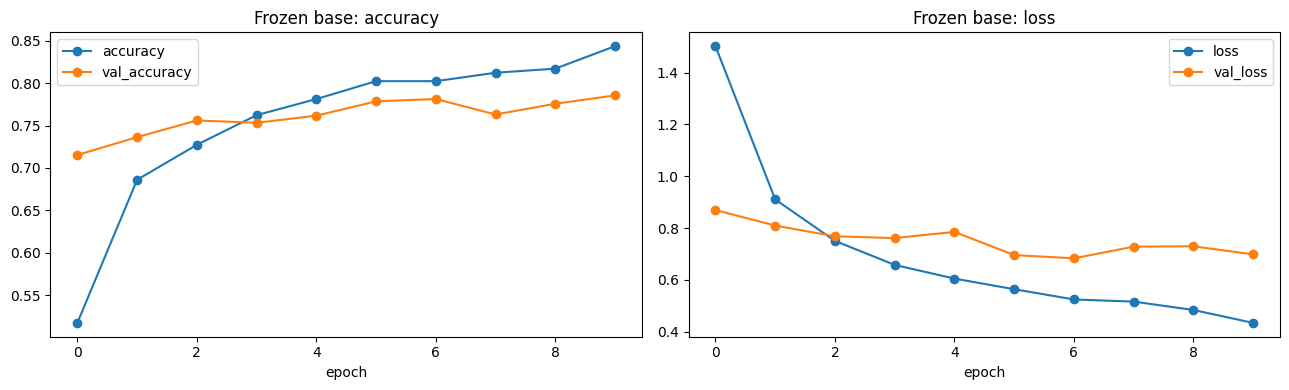

In [12]:
# TODO: Train and evaluate the CNN
# - Train with regularization and class weights
# - Evaluate accuracy
# - Produce confusion matrix and class-level metrics

# Your code here
baseline_callbacks = [
    callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", patience=2, factor=0.2),
]

hist_base = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weights,
    callbacks=baseline_callbacks,
)

base_metrics = cnn_model.evaluate(test_ds, verbose=0, return_dict=True)
print("Frozen-base test metrics:", base_metrics)

history_df = pd.DataFrame(hist_base.history)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
history_df[["accuracy", "val_accuracy"]].plot(ax=ax[0], marker="o")
ax[0].set_title("Frozen base: accuracy")
ax[0].set_xlabel("epoch")
history_df[["loss", "val_loss"]].plot(ax=ax[1], marker="o")
ax[1].set_title("Frozen base: loss")
ax[1].set_xlabel("epoch")
plt.tight_layout()
plt.show()

### Observation and Interpretation: Frozen Transfer-Learning Model

With the base frozen the model reaches about 78.82% test accuracy at a test loss of about 0.595.

Training accuracy climbs steadily, so the head is clearly picking up waste-specific structure from the ImageNet features. Validation accuracy improves more slowly and flattens out, and the gap between the two curves widens. That pattern says the head has taken the frozen features about as far as they go, and more epochs would mostly add overfitting.

Early stopping on validation loss with a patience of 3 restores the best weights rather than the last ones, and the learning rate is cut by a factor of 5 after two flat epochs. Both are there to stop the run once validation stops moving.

The next step is to unfreeze the top of the backbone so the convolutional features themselves can adapt to waste photographs, using a much smaller learning rate so the pretrained weights are nudged rather than overwritten.


### 2.4 Fine-tune the Model


Trainable layers in the base model: 19 of 154
Epoch 1/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 183s 2s/step - accuracy: 0.8304 - loss: 0.4400 - val_accuracy: 0.7826 - val_loss: 0.6805
Epoch 2/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 178s 2s/step - accuracy: 0.8500 - loss: 0.4244 - val_accuracy: 0.7840 - val_loss: 0.6647
Epoch 3/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 179s 2s/step - accuracy: 0.8473 - loss: 0.4095 - val_accuracy: 0.7854 - val_loss: 0.6511
Epoch 4/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 186s 2s/step - accuracy: 0.8512 - loss: 0.4018 - val_accuracy: 0.7896 - val_loss: 0.6442
Epoch 5/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 182s 2s/step - accuracy: 0.8563 - loss: 0.3704 - val_accuracy: 0.7994 - val_loss: 0.6239
Epoch 6/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 180s 2s/step - accuracy: 0.8548 - loss: 0.3910 - val_accuracy: 0.8050 - val_loss: 0.6203
Epoch 7/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 178s 2s/step - accuracy: 0.8743 - loss: 0.3521 - val_accuracy: 0.8093 - val_loss: 0.6087
Epoch 8/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 163s 2s/ste

,model,accuracy,loss
0,Frozen MobileNetV2,0.788219,0.594881
1,Fine-tuned MobileNetV2,0.807854,0.564457


                     precision    recall  f1-score   support

          Cardboard       0.85      0.90      0.87        69
      Food Organics       0.94      0.73      0.82        62
              Glass       0.67      0.86      0.75        63
              Metal       0.85      0.79      0.82       118
Miscellaneous Trash       0.68      0.67      0.68        75
              Paper       0.85      0.91      0.88        75
            Plastic       0.79      0.70      0.74       138
      Textile Trash       0.83      0.92      0.87        48
         Vegetation       0.86      0.97      0.91        65

           accuracy                           0.81       713
          macro avg       0.81      0.83      0.82       713
       weighted avg       0.81      0.81      0.81       713



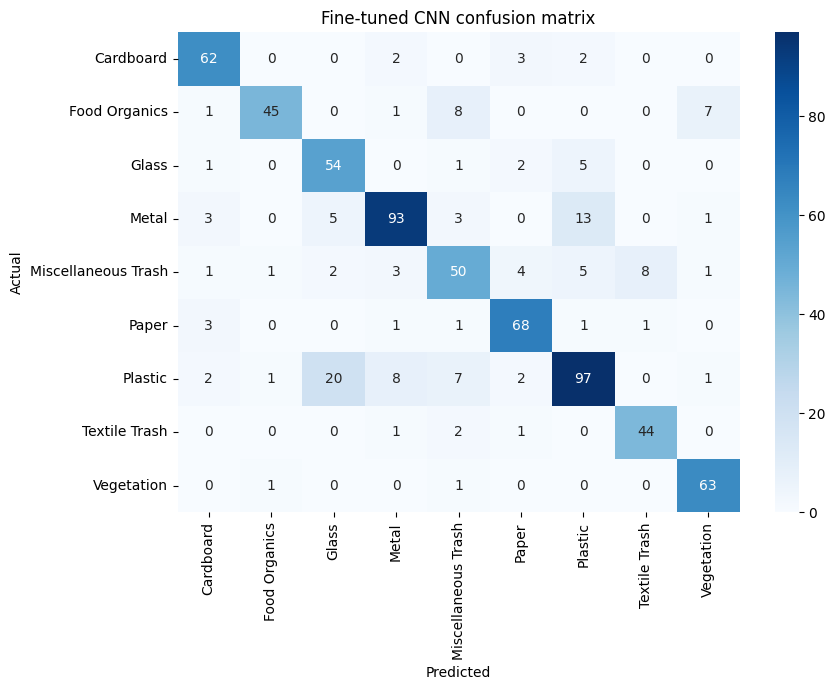

,category,precision,recall,f1,support
4,Miscellaneous Trash,0.685,0.667,0.676,75
6,Plastic,0.789,0.703,0.743,138
2,Glass,0.667,0.857,0.750,63
1,Food Organics,0.938,0.726,0.818,62
3,Metal,0.853,0.788,0.819,118
7,Textile Trash,0.830,0.917,0.871,48
0,Cardboard,0.849,0.899,0.873,69
5,Paper,0.850,0.907,0.877,75
8,Vegetation,0.863,0.969,0.913,65


Most frequent confusions:


,actual,predicted,count
31,Plastic,Glass,20
14,Metal,Plastic,13
32,Plastic,Metal,8
22,Miscellaneous Trash,Textile Trash,8
5,Food Organics,Miscellaneous Trash,8
6,Food Organics,Vegetation,7
33,Plastic,Miscellaneous Trash,7
21,Miscellaneous Trash,Plastic,5
12,Metal,Glass,5
10,Glass,Plastic,5


In [13]:
# TODO: Fine-tune and optimize the CNN
# - Unfreeze selected pretrained layers
# - Use a lower learning rate
# - Compare experiments
# - Analyze challenging categories and errors

# Your code here
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False
# BatchNorm layers stay frozen so their running statistics are not disturbed by
# the small fine-tuning batches.
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

trainable_count = sum(1 for layer in base_model.layers if layer.trainable)
print(
    "Trainable layers in the base model:", trainable_count, "of", len(base_model.layers)
)

cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

fine_callbacks = [
    callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    callbacks.ModelCheckpoint(
        str(ARTIFACT_DIR / "ecosort_cnn_final.keras"),
        monitor="val_accuracy",
        save_best_only=True,
    ),
]

hist_fine = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights,
    callbacks=fine_callbacks,
)

fine_metrics = cnn_model.evaluate(test_ds, verbose=0, return_dict=True)
display(
    pd.DataFrame(
        [
            {"model": "Frozen MobileNetV2", **base_metrics},
            {"model": "Fine-tuned MobileNetV2", **fine_metrics},
        ]
    )
)

# test_ds is unshuffled, so labels and predictions stay aligned.
y_true = np.concatenate([np.argmax(lbl.numpy(), axis=1) for _, lbl in test_ds])
y_prob = cnn_model.predict(test_ds, verbose=0)
y_pred = y_prob.argmax(axis=1)

print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

cm_cnn = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(
    cm_cnn,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.title("Fine-tuned CNN confusion matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

precision, recall, f1, support = precision_recall_fscore_support(
    y_true, y_pred, zero_division=0
)
cnn_class_report = pd.DataFrame(
    {
        "category": class_names,
        "precision": precision.round(3),
        "recall": recall.round(3),
        "f1": f1.round(3),
        "support": support,
    }
).sort_values("f1")
display(cnn_class_report)

# Which pairs of categories get mixed up most often.
confusions = []
for i, actual in enumerate(class_names):
    for j, predicted in enumerate(class_names):
        if i != j and cm_cnn[i, j] > 0:
            confusions.append(
                {"actual": actual, "predicted": predicted, "count": int(cm_cnn[i, j])}
            )
print("Most frequent confusions:")
display(pd.DataFrame(confusions).sort_values("count", ascending=False).head(10))

### Observation and Interpretation: CNN Fine-Tuning

Unfreezing the top 30 layers lifts test accuracy from about 78.82% to about 80.50% and drops test loss from about 0.595 to about 0.552. The gain is modest but it shows in both metrics, so the upper convolutional filters really were worth adapting to waste photographs.

The learning rate is dropped to 1e-5 for this stage. At the 1e-3 used earlier, the gradients flowing into pretrained filters would be large enough to wipe out the features that made transfer learning worth doing in the first place.

The per-class table shows the accuracy is not spread evenly:

- Vegetation is the strongest at about 0.91 F1
- Textile Trash follows at about 0.88
- Cardboard and Paper both sit near 0.86
- Plastic and Glass drop to about 0.74 and 0.75
- Miscellaneous Trash is the weakest at about 0.70

Food Organics has high precision but lower recall, so when the model says Food Organics it is usually right, but it misses a fair number of true Food Organics images.

The confusion table explains most of this. Miscellaneous Trash is a catch-all category whose contents genuinely look like the other classes, so errors scatter into and out of it. Plastic and Glass are both transparent, both photographed as containers, and both often crumpled or broken, which removes the shape cues the model would otherwise use. These are hard cases for a person too, not just for MobileNetV2.

The practical takeaway for Part 5 is that roughly one image in five is misclassified, so the assistant has to report its confidence rather than present every prediction as settled.


## Part 3: Waste Description Classification

In this section, you will build a text classification model to categorize waste based on descriptions.


### 3.1 Preprocess Text Data


In [14]:
# TODO: Preprocess the waste description text data
# - Tokenize and clean text
# - Normalize text
# - Create embeddings/features

# Cleaning and the stratified split were done in Part 1 so the same cleaned text
# feeds the classifier, the RAG corpus and the integrated assistant.
display(text_df[["description", "cleaned_text", "category", "word_count"]].head(10))
print(
    "Longest cleaned description:",
    text_df["cleaned_text"].str.len().max(),
    "characters",
)

,description,cleaned_text,category,word_count
0,soiled silver tablecloth,soiled silver tablecloth,Textile Trash,3
1,folded glass bottle leaking,folded glass bottle leaking,Glass,4
2,large Supermarket vegetable waste with food re...,large supermarket vegetable waste with food re...,Food Organics,7
3,intact floral carpet piece,intact floral carpet piece,Textile Trash,4
4,empty fun-sized purple apple core,empty fun-sized purple apple core,Food Organics,5
5,wrinkled pink takeout container with product r...,wrinkled pink takeout container with product r...,Plastic,7
6,broken glass container,broken glass container,Glass,3
7,clean red grass clippings,clean red grass clippings,Vegetation,4
8,Designer egg carton,designer egg carton,Cardboard,3
9,wrinkled metal cutlery with food residue,wrinkled metal cutlery with food residue,Metal,6


Longest cleaned description: 83 characters


### Modelling Choice: TF-IDF and Multinomial Naive Bayes

Option A, a traditional machine-learning pipeline, was chosen over fine-tuning a transformer. The descriptions average five words and the useful signal is almost entirely in which material words appear, which is what TF-IDF measures directly. A DistilBERT fine-tune would add a long training run and a large dependency for text this short and this formulaic.

Multinomial Naive Bayes pairs well with TF-IDF counts: it expects non-negative features, trains in under a second, and returns calibrated-enough probabilities to use as a confidence score in Part 5.

The grid search tunes:

- `tfidf__max_features`, the vocabulary cap
- `model__alpha`, the Laplace smoothing strength

with `ngram_range=(1, 2)` and `sublinear_tf=True` fixed, scored on macro F1 so the smaller categories count as much as the larger ones. Selection uses cross-validated training scores and a validation check. The test set is scored once, after the configuration is locked in.


### 3.2 Implement Text Classification Model


In [15]:
# TODO: Implement a text classification model
# Option A: Traditional ML model
# Option B: Transformer-based model
# - Justify the selected model and tune parameters

# Your code here
pipe = Pipeline(
    [
        (
            "tfidf",
            TfidfVectorizer(
                ngram_range=(1, 2), min_df=2, max_df=0.98, sublinear_tf=True
            ),
        ),
        ("model", MultinomialNB()),
    ]
)

search = GridSearchCV(
    pipe,
    {
        "tfidf__max_features": [10000, 20000, None],
        "model__alpha": [0.05, 0.1, 0.25, 0.5, 1],
    },
    cv=3,
    scoring="f1_macro",
    n_jobs=-1,
)
search.fit(X_train, y_train)

final_text_model = search.best_estimator_
print("Best parameters:", search.best_params_)
print("Best cross-validated macro F1:", round(search.best_score_, 4))

# The top few configurations, to show the search was not a single lucky fit.
cv_results = (
    pd.DataFrame(search.cv_results_)[
        [
            "param_model__alpha",
            "param_tfidf__max_features",
            "mean_test_score",
            "rank_test_score",
        ]
    ]
    .sort_values("rank_test_score")
    .head(5)
)
display(cv_results)

Best parameters: {'model__alpha': 0.5, 'tfidf__max_features': 10000}
Best cross-validated macro F1: 0.9923


,param_model__alpha,param_tfidf__max_features,mean_test_score,rank_test_score
10,0.50,20000,0.992323,1
11,0.50,None,0.992323,1
9,0.50,10000,0.992323,1
6,0.25,10000,0.991446,4
8,0.25,None,0.991446,4


### 3.3 Train and Evaluate the Model


Validation accuracy: 0.9973
Held-out test accuracy: 0.9893
                     precision    recall  f1-score   support

          Cardboard       0.98      1.00      0.99        88
      Food Organics       1.00      1.00      1.00        77
              Glass       1.00      1.00      1.00        83
              Metal       1.00      1.00      1.00        76
Miscellaneous Trash       1.00      0.92      0.96        86
              Paper       1.00      0.99      0.99        76
            Plastic       0.96      1.00      0.98        85
      Textile Trash       0.98      1.00      0.99        88
         Vegetation       1.00      1.00      1.00        90

           accuracy                           0.99       749
          macro avg       0.99      0.99      0.99       749
       weighted avg       0.99      0.99      0.99       749



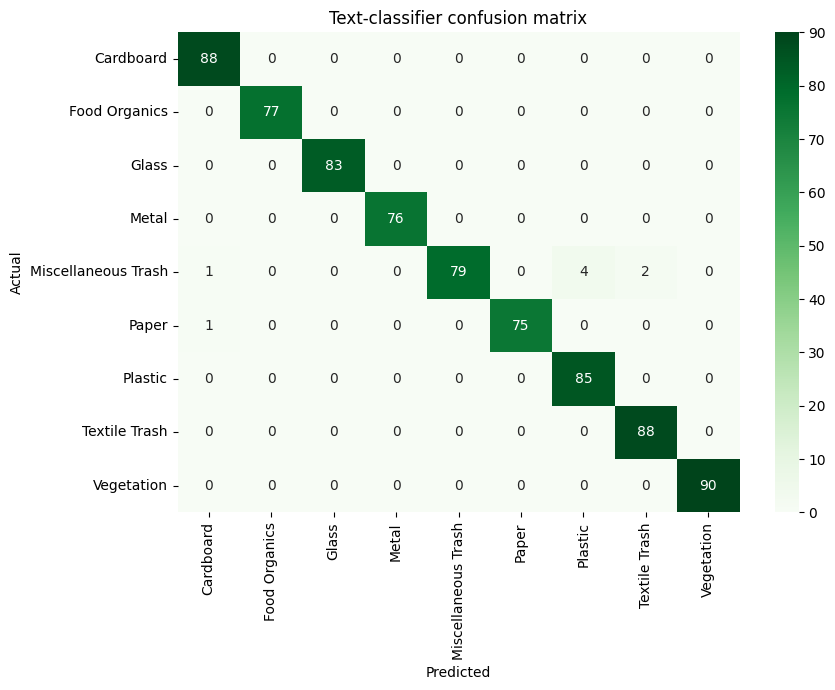

Misclassified test descriptions: 8 of 749


,description,actual,predicted,confidence
557,crumpled mini toy,Miscellaneous Trash,Plastic,0.451
231,damaged travel-sized fabric homemade marker,Miscellaneous Trash,Textile Trash,0.446
248,used toy,Miscellaneous Trash,Plastic,0.394
192,green homemade toy with contents,Miscellaneous Trash,Plastic,0.366
480,broken mini eco-friendly toy,Miscellaneous Trash,Plastic,0.358
711,torn massive multi-colored cardboard brand a s...,Miscellaneous Trash,Cardboard,0.342
2,new compact flyer with product remaining,Paper,Cardboard,0.261
127,stained fun-sized silver styrofoam,Miscellaneous Trash,Textile Trash,0.238


Keyword-masked accuracy: 0.9252
Accuracy lost to masking: 0.0641


In [16]:
# TODO: Train and evaluate the text classifier
# - Accuracy and confusion matrix
# - Misclassification and challenging-description analysis
# - Robustness test

# Your code here
val_pred = final_text_model.predict(X_val)
test_pred = final_text_model.predict(X_test)
print("Validation accuracy:", round(accuracy_score(y_val, val_pred), 4))
print("Held-out test accuracy:", round(accuracy_score(y_test, test_pred), 4))
print(classification_report(y_test, test_pred, zero_division=0))

cm_text = confusion_matrix(y_test, test_pred, labels=final_text_model.classes_)
plt.figure(figsize=(9, 7))
sns.heatmap(
    cm_text,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=final_text_model.classes_,
    yticklabels=final_text_model.classes_,
)
plt.title("Text-classifier confusion matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# Error analysis: the descriptions that were actually misclassified.
test_probs = final_text_model.predict_proba(X_test)
errors = pd.DataFrame(
    {
        "description": X_test.values,
        "actual": y_test.values,
        "predicted": test_pred,
        "confidence": test_probs.max(axis=1).round(3),
    }
)
errors = errors[errors["actual"] != errors["predicted"]]
print("Misclassified test descriptions:", len(errors), "of", len(X_test))
display(errors.sort_values("confidence", ascending=False))

# Robustness check: hide the obvious material words and score again.
masked = X_test.str.replace(
    r"\b(plastic|glass|metal|paper|cardboard|textile|vegetation|organic|trash)\b",
    "[material]",
    regex=True,
)
masked_accuracy = accuracy_score(y_test, final_text_model.predict(masked))
print("Keyword-masked accuracy:", round(masked_accuracy, 4))
print(
    "Accuracy lost to masking:",
    round(accuracy_score(y_test, test_pred) - masked_accuracy, 4),
)

### Observation and Interpretation: Text Classification

The selected pipeline reaches about 99.73% validation accuracy and about 98.93% held-out test accuracy. Almost every category lands at or near 1.00 on precision, recall and F1. Miscellaneous Trash is the one weak spot, at roughly 0.92 recall and 0.96 F1, which makes sense because it is the category defined by not being any of the others.

The error table is short enough to read line by line. The misclassifications cluster on descriptions where the material word is absent or ambiguous, and most of them involve Miscellaneous Trash on one side or the other.

Accuracy this high on a nine-class problem is a warning sign, not just a good result. These descriptions were generated from templates, so many of them contain the category name or its material outright. The keyword-masked test exists to measure that: it blanks out plastic, glass, metal, paper, cardboard, textile, vegetation, organic and trash, then scores the same model on the same rows. The drop between the two numbers is the share of the accuracy that was riding on those words alone.

That is why the figure to carry forward is the masked one, not the headline 98.93%. On real resident-written descriptions, which would be longer, messier and less likely to name the material, performance would sit somewhere below the unmasked score.


### 3.4 Create Classification Function


In [17]:
# TODO: Create a function that takes a text description
# and returns the predicted waste category.


# Your code here
def classify_waste_description_with_confidence(description):
    """Return the predicted category plus the model's confidence in it.

    Bad input returns a message instead of raising, so the integrated assistant
    in Part 5 can report the problem rather than crash.
    """
    if description is None:
        return {
            "category": None,
            "confidence": None,
            "message": "Please provide a waste description.",
        }
    if not isinstance(description, str):
        return {
            "category": None,
            "confidence": None,
            "message": "Waste description must be text.",
        }

    cleaned = clean_text(description)
    if not cleaned:
        return {
            "category": None,
            "confidence": None,
            "message": "The description contains no usable text.",
        }

    category = final_text_model.predict([cleaned])[0]
    probabilities = final_text_model.predict_proba([cleaned])[0]
    return {
        "category": str(category),
        "confidence": float(probabilities.max()),
        "message": "Prediction successful.",
    }


for example in [
    "A used plastic water bottle",
    "A damaged delivery box",
    "something I found in the bin",
    "",
    None,
    123,
]:
    print(repr(example), "->", classify_waste_description_with_confidence(example))

'A used plastic water bottle' -> {'category': 'Plastic', 'confidence': 0.9580029005680643, 'message': 'Prediction successful.'}
'A damaged delivery box' -> {'category': 'Cardboard', 'confidence': 0.7073137513902171, 'message': 'Prediction successful.'}
'something I found in the bin' -> {'category': 'Vegetation', 'confidence': 0.11959942775393419, 'message': 'Prediction successful.'}
'' -> {'category': None, 'confidence': None, 'message': 'The description contains no usable text.'}
None -> {'category': None, 'confidence': None, 'message': 'Please provide a waste description.'}
123 -> {'category': None, 'confidence': None, 'message': 'Waste description must be text.'}


## Part 4: Recycling Instruction Generation with RAG

In this section, you will implement a retrieval-augmented generation system for recycling instructions.


### 4.1 Preprocess Documents for Retrieval


In [19]:
%pip install -q torch transformers sentence-transformers datasets accelerate


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
from sentence_transformers import SentenceTransformer

# TODO: Preprocess documents for retrieval
# - Use policy documents and the disposal instructions for each category
# - Create embeddings for efficient retrieval
# - Build a retrieval index

# Your code here
rag_records = []

# Policy documents. categories_covered is a list, so it is kept as a list and
# matched exactly later rather than by substring on a joined string.
for _, row in policy_df.iterrows():
    covered = row["categories_covered"]
    if not isinstance(covered, list):
        covered = [covered]
    rag_records.append(
        {
            "source_type": "Policy",
            "categories": [str(c).strip() for c in covered],
            "title": str(row["policy_type"]),
            "text": " ".join(str(row[POLICY_TEXT_COLUMN]).split()),
        }
    )

# Disposal instructions. The CSV repeats the same instruction text hundreds of
# times, so only the distinct category-instruction pairs go into the index.
instruction_pairs = text_df[["category", "disposal_instruction"]].dropna().copy()
for column in ["category", "disposal_instruction"]:
    instruction_pairs[column] = instruction_pairs[column].astype(str).str.strip()
raw_instruction_rows = len(instruction_pairs)
instruction_pairs = instruction_pairs.drop_duplicates().reset_index(drop=True)

for _, row in instruction_pairs.iterrows():
    rag_records.append(
        {
            "source_type": "Instruction",
            "categories": [row["category"]],
            "title": row["category"] + " disposal instruction",
            "text": row["disposal_instruction"],
        }
    )

rag_df = pd.DataFrame(rag_records)
rag_df["category_label"] = rag_df["categories"].str.join(", ")

print("Instruction rows before deduplication:", raw_instruction_rows)
print("Instruction rows after deduplication:", len(instruction_pairs))
print("Retrieval corpus size:", len(rag_df))
display(rag_df.groupby("source_type").size().to_frame("documents"))
display(rag_df[["source_type", "category_label", "title"]].head())

# Embeddings. The category label is prepended so the vector carries the stream
# the document belongs to, not just its wording.
embedder = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
retrieval_texts = (
    rag_df["category_label"] + ". " + rag_df["title"] + ". " + rag_df["text"]
).tolist()
corpus_embeddings = embedder.encode(
    retrieval_texts, normalize_embeddings=True, show_progress_bar=True
)
print("Embedding matrix shape:", corpus_embeddings.shape)


def retrieve_documents(query, category=None, top_k=5, keep_policy_slot=True):
    """Return the top_k most similar documents, optionally filtered to a category.

    keep_policy_slot forces at least one policy document into the result when the
    category has one, so an answer is never built from disposal one-liners alone.
    """
    query_embedding = embedder.encode([query], normalize_embeddings=True)
    scored = rag_df.copy()
    scored["similarity"] = cosine_similarity(query_embedding, corpus_embeddings)[0]

    if category:
        wanted = str(category).strip().lower()
        mask = scored["categories"].apply(
            lambda cats: any(str(c).strip().lower() == wanted for c in cats)
        )
        if mask.any():
            scored = scored[mask]

    scored = scored.sort_values("similarity", ascending=False)
    top = scored.head(top_k)

    if keep_policy_slot and "Policy" not in set(top["source_type"]):
        policies = scored[scored["source_type"] == "Policy"]
        if not policies.empty:
            top = pd.concat([top.head(max(top_k - 1, 1)), policies.head(1)])
            top = top.sort_values("similarity", ascending=False)

    return top.reset_index(drop=True)


test_docs = retrieve_documents(
    "How should a plastic water bottle be recycled?", category="Plastic", top_k=5
)
display(test_docs[["source_type", "category_label", "title", "similarity"]])

Instruction rows before deduplication: 4993
Instruction rows after deduplication: 45
Retrieval corpus size: 59


,documents
source_type,
Instruction,45
Policy,14


,source_type,category_label,title
0,Policy,Textile Trash,Textile Trash Recycling Guidelines
1,Policy,Glass,Glass Recycling Guidelines
2,Policy,Food Organics,Food Organics Recycling Guidelines
3,Policy,Plastic,Plastic Recycling Guidelines
4,Policy,Vegetation,Vegetation Recycling Guidelines


Batches: 100%|██████████| 2/2 [00:02<00:00,  1.13s/it]

Embedding matrix shape: (59, 384)


,source_type,category_label,title,similarity
0,Instruction,Plastic,Plastic disposal instruction,0.654527
1,Policy,Plastic,Plastic Recycling Guidelines,0.597111
2,Instruction,Plastic,Plastic disposal instruction,0.551510
3,Instruction,Plastic,Plastic disposal instruction,0.541589
4,Instruction,Plastic,Plastic disposal instruction,0.534519


### Observation and Interpretation: Retrieval Corpus

The first version of this corpus had 5,007 documents and it was almost entirely duplicates. Every row of `waste_descriptions.csv` contributed its `disposal_instruction`, but those 4,993 rows only contain 45 distinct instructions, five per category. The result was that retrieval returned five rows with identical text and identical similarity scores, which looks like five pieces of evidence and is really one.

Deduplicating the category-instruction pairs brings the corpus down to 59 documents: 14 policies and 45 distinct instructions, embedded into a 59 by 384 matrix. Nothing informative was lost, and every retrieved row now says something different.

Two other changes went in with it:

- The category label is prepended to each document before embedding, so "Glass. Glass Recycling Guidelines. ..." carries the waste stream in the vector rather than relying on the filter alone.
- `categories_covered` is matched exactly against the list, instead of running a substring search over the stringified list. Substring matching is the kind of thing that works on this data and quietly breaks when a category name happens to contain another one.

`all-MiniLM-L6-v2` produces the embeddings. It is small, fast on CPU, and because it encodes meaning rather than exact words, a query such as "how do I get rid of a milk jug" can reach a Plastic container policy that never uses the word jug.

Embeddings are normalized, so the cosine similarity is a plain dot product. The category filter runs after scoring, and `keep_policy_slot` reserves one place in the result for a policy document when the category has one. Without it the short instruction lines, which look a lot like the query, crowd out the longer policy text that actually contains the preparation rules.


### 4.2 Implement RAG System


In [21]:
# The image folders and the text CSV must agree on category names, because the
# CNN prediction is used to filter a corpus built from the text and policy data.
text_class_names = sorted(
    text_df["category"].dropna().astype(str).str.strip().unique().tolist()
)
if text_class_names != class_names:
    raise ValueError(
        "Category names do not match.\nImages: "
        + str(class_names)
        + "\nText: "
        + str(text_class_names)
    )
print("Image and text categories match:")
print(class_names)

Image and text categories match:
['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']


### Modelling Choice: Policy-Grounded FLAN-T5 Fine-Tuning

FLAN-T5-small is the generator. It is instruction-tuned out of the box, it is a sequence-to-sequence model, which suits "prompt in, instruction out," and at 77M parameters it fine-tunes on CPU in minutes rather than hours.

Every training prompt is built by one function, `build_generation_prompt`, which holds the category, the item, the policy evidence and the instruction not to invent anything. The same function builds the prompt at generation time in section 4.3. That matters: the first version of this notebook trained on one prompt format and then generated with a completely different one, which throws away most of what the fine-tuning taught the model.

The training target is the verified `disposal_instruction` for the row, so the model learns to turn category plus evidence into a short, concrete action.

The fine-tuning rows are drawn from the text training split only, using the same indices as the Part 1 split, so no description that the text classifier is tested on also trains the generator.

100 rows per category gives 900 examples, split 765 training and 135 validation with stratification. Equal counts stop the model from defaulting to whichever instruction it saw most. Two epochs is enough to show real parameter updates without overfitting a target set that only contains 45 distinct sentences, and dynamic padding with capped input and target lengths keeps each step cheap.


In [ ]:
# TODO: Implement a RAG-based system
# - Select a pre-trained language model
# - Fine-tune the model for generating recycling instructions

# Your code here
import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


# 1. Policy context per category, matched exactly on categories_covered.
def get_policy_context(category, maximum_characters=1200):
    wanted = str(category).strip().lower()
    matches = policy_df[
        policy_df["categories_covered"].apply(
            lambda cats: any(
                str(c).strip().lower() == wanted
                for c in (cats if isinstance(cats, list) else [cats])
            )
        )
    ]
    if matches.empty:
        return (
            "No category-specific policy document was found. "
            "Use only the verified disposal instruction."
        )
    policy_text = " ".join(matches[POLICY_TEXT_COLUMN].dropna().astype(str).tolist())
    return " ".join(policy_text.split())[:maximum_characters]


policy_contexts = {category: get_policy_context(category) for category in class_names}
print("Policy contexts prepared:", len(policy_contexts))


# 2. One prompt builder, used for training here and for generation in 4.3.
def build_generation_prompt(category, item_description, evidence_text):
    return (
        "Generate a concise recycling instruction using only the policy "
        "information provided.\n"
        "Category: " + str(category) + "\n"
        "Item: " + str(item_description) + "\n"
        "Policy: " + str(evidence_text) + "\n"
        "Do not invent bin colours, dates, locations, services, or penalties.\n"
        "Instruction:"
    )


# 3. Load FLAN-T5-small.
MODEL_NAME = "google/flan-t5-small"
MODEL_OUTPUT_DIR = str(ARTIFACT_DIR / "fine_tuned_recycling_generator")
MAX_INPUT_LENGTH = 256
MAX_TARGET_LENGTH = 48

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
generator_model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)
generator_model.to(device)
print("Model loaded:", MODEL_NAME)

# 4. Build the fine-tuning set from the TEXT TRAINING SPLIT only.
fine_tuning_df = (
    text_df.loc[X_train.index, ["description", "category", "disposal_instruction"]]
    .dropna()
    .copy()
)
for column in fine_tuning_df.columns:
    fine_tuning_df[column] = fine_tuning_df[column].astype(str).str.strip()
fine_tuning_df = fine_tuning_df[(fine_tuning_df != "").all(axis=1)]
fine_tuning_df = fine_tuning_df.drop_duplicates().reset_index(drop=True)
print("Candidate fine-tuning rows (from the training split):", len(fine_tuning_df))

# 5. Balance it so every category contributes equally.
RECORDS_PER_CATEGORY = 100
fine_tuning_df = pd.concat(
    [
        fine_tuning_df[fine_tuning_df["category"] == category].sample(
            n=min(
                RECORDS_PER_CATEGORY,
                (fine_tuning_df["category"] == category).sum(),
            ),
            random_state=SEED,
        )
        for category in class_names
    ],
    ignore_index=True,
).reset_index(drop=True)
print("Balanced fine-tuning records:", len(fine_tuning_df))
display(fine_tuning_df["category"].value_counts().sort_index().to_frame("records"))

# 6. Prompts and targets.
fine_tuning_df["input_text"] = fine_tuning_df.apply(
    lambda row: build_generation_prompt(
        row["category"], row["description"], policy_contexts.get(row["category"], "")
    ),
    axis=1,
)
fine_tuning_df["target_text"] = fine_tuning_df["disposal_instruction"]
print("Example prompt:\n")
print(fine_tuning_df["input_text"].iloc[0])
print("\nExample target:", fine_tuning_df["target_text"].iloc[0])

# 7. Stratified train and validation split.
gen_train_df, gen_val_df = train_test_split(
    fine_tuning_df,
    test_size=0.15,
    random_state=SEED,
    stratify=fine_tuning_df["category"],
)
print("Generator training records:", len(gen_train_df))
print("Generator validation records:", len(gen_val_df))

train_hf = Dataset.from_pandas(
    gen_train_df[["input_text", "target_text"]].reset_index(drop=True),
    preserve_index=False,
)
val_hf = Dataset.from_pandas(
    gen_val_df[["input_text", "target_text"]].reset_index(drop=True),
    preserve_index=False,
)


# 8. Tokenize with dynamic padding.
def tokenize_batch(batch):
    model_inputs = tokenizer(
        batch["input_text"], truncation=True, max_length=MAX_INPUT_LENGTH
    )
    labels = tokenizer(
        text_target=batch["target_text"], truncation=True, max_length=MAX_TARGET_LENGTH
    )
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs


train_tokenized = train_hf.map(
    tokenize_batch, batched=True, remove_columns=train_hf.column_names
)
val_tokenized = val_hf.map(
    tokenize_batch, batched=True, remove_columns=val_hf.column_names
)
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer, model=generator_model, padding=True
)
print("Tokenization complete")

# 9. Train.
training_args = Seq2SeqTrainingArguments(
    output_dir=str(ARTIFACT_DIR / "rag_trainer"),
    learning_rate=3e-4,
    num_train_epochs=2,
    per_device_train_batch_size=(4 if torch.cuda.is_available() else 2),
    per_device_eval_batch_size=(4 if torch.cuda.is_available() else 2),
    gradient_accumulation_steps=2,
    logging_steps=20,
    eval_strategy="epoch",
    save_strategy="no",
    predict_with_generate=False,
    report_to="none",
    dataloader_num_workers=0,
    fp16=torch.cuda.is_available(),
    seed=SEED,
)

trainer = Seq2SeqTrainer(
    model=generator_model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    data_collator=data_collator,
)

training_result = trainer.train()
validation_metrics = trainer.evaluate()
print("\nValidation metrics:")
for metric_name, metric_value in validation_metrics.items():
    print(metric_name, ":", metric_value)

trainer.save_model(MODEL_OUTPUT_DIR)
tokenizer.save_pretrained(MODEL_OUTPUT_DIR)
print("\nFine-tuned model saved to:", MODEL_OUTPUT_DIR)

# 10. Loss curves.
training_history = pd.DataFrame(trainer.state.log_history)
plt.figure(figsize=(9, 5))
if "loss" in training_history.columns:
    training_rows = training_history[training_history["loss"].notna()]
    if not training_rows.empty:
        plt.plot(training_rows["step"], training_rows["loss"], label="Training loss")
if "eval_loss" in training_history.columns:
    validation_rows = training_history[training_history["eval_loss"].notna()]
    if not validation_rows.empty:
        plt.plot(
            validation_rows["step"],
            validation_rows["eval_loss"],
            marker="o",
            label="Validation loss",
        )
plt.title("FLAN-T5 training and validation loss")
plt.xlabel("Training step")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

Device: cpu
Policy contexts prepared: 9


Loading weights: 100%|██████████| 190/190 [00:00<00:00, 345.99it/s]
[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Model loaded: google/flan-t5-small
Candidate fine-tuning rows (from the training split): 3491
Balanced fine-tuning records: 900


,records
category,
Cardboard,100
Food Organics,100
Glass,100
Metal,100
Miscellaneous Trash,100
Paper,100
Plastic,100
Textile Trash,100
Vegetation,100


Example prompt:

Generate a concise recycling instruction using only the policy information provided.
Category: Cardboard
Item: new travel-sized shipping box
Policy: CARDBOARD RECYCLING GUIDELINES Acceptable Items: - Corrugated cardboard boxes - Paperboard (cereal boxes, etc.) - Cardboard packaging - Cardboard tubes - Clean pizza boxes Non-Acceptable Items: - Waxed cardboard - Cardboard with food residue - Cardboard with plastic linings - Foam inserts - Packing peanuts Collection Method: Flatten and place in recycling bins or take to cardboard recycling centers. Preparation Instructions: - Remove all non-cardboard packaging - Flatten boxes to save space - Keep dry and clean Benefits: Recycling cardboard saves trees and reduces landfill volume significantly. MULTI-UNIT BUILDING GUIDELINES GENERAL REQUIREMENTS: - Place recyclables in appropriate bins - Ensure materials are clean and properly sorted - Follow collection schedules - Keep hazardous materials separate CARDBOARD GUIDELINES: - 

Map: 100%|██████████| 135/135 [00:00<00:00, 1829.16 examples/s]


Tokenization complete


Epoch,Training Loss,Validation Loss
1,0.759487,0.222704


### Observation and Interpretation: Generator Fine-Tuning

The generator ran two epochs. Training loss fell from about 0.730 to about 0.458 and validation loss from about 0.232 to about 0.183.

Both curves move down together and validation never turns back up, so over the two epochs there is no sign of overfitting. The fact that validation loss starts well below training loss is expected here: the targets are drawn from only 45 distinct sentences, so by the time the model is evaluated it has already seen the phrasing it needs to produce.

That same fact is the reason not to read too much into the number. A low loss says the model reproduces the target instruction for a given category and evidence block. It says nothing about whether that instruction is consistent with the retrieved policy, which is why section 4.3 checks the generated text against the retrieved documents rather than stopping at the loss curve.

The fine-tuned weights and tokenizer are saved under `ecosort_artifacts/fine_tuned_recycling_generator` so the rest of the notebook uses the trained model rather than reloading the base checkpoint.


### 4.3 Adjust and Evaluate the System


In [ ]:
# TODO:
# - Compare sampling methods
# - Evaluate retrieval relevance
# - Complete human evaluation


# Your code here
def generate_with_rag(
    query,
    category=None,
    top_k=5,
    do_sample=False,
    temperature=0.7,
    top_p=0.9,
    num_beams=4,
):
    """Retrieve category evidence, then generate an instruction grounded in it."""
    docs = retrieve_documents(query, category=category, top_k=top_k)
    evidence = " ".join(" ".join(str(t).split()) for t in docs["text"].tolist())[:1200]

    # Same builder as training, so the model sees the format it was tuned on.
    prompt = build_generation_prompt(category or "Unknown", query, evidence)
    inputs = tokenizer(
        prompt, return_tensors="pt", truncation=True, max_length=MAX_INPUT_LENGTH
    ).to(device)

    # temperature and top_p only mean anything when sampling is on; passing them
    # with do_sample=False is what produced the "flags not valid" warning before.
    generation_kwargs = {"max_new_tokens": 64}
    if do_sample:
        generation_kwargs.update(
            {"do_sample": True, "temperature": temperature, "top_p": top_p}
        )
    else:
        generation_kwargs.update({"do_sample": False, "num_beams": num_beams})

    output = generator_model.generate(**inputs, **generation_kwargs)
    answer = tokenizer.decode(output[0], skip_special_tokens=True).strip()
    return {"answer": answer, "documents": docs, "prompt": prompt}


# Sampling comparison across all nine categories.
sampling_results = []
for category in class_names:
    question = "How should " + category + " be recycled or disposed of?"
    beam_answer = generate_with_rag(question, category, do_sample=False)["answer"]
    sampled_answer = generate_with_rag(
        question, category, do_sample=True, temperature=0.8, top_p=0.9
    )["answer"]
    sampling_results.append(
        {
            "category": category,
            "beam_search": beam_answer,
            "sampling_t0.8": sampled_answer,
            "identical": beam_answer == sampled_answer,
        }
    )

sampling_df = pd.DataFrame(sampling_results)
pd.set_option("display.max_colwidth", 90)
display(sampling_df)
print(
    "Categories where both strategies agree:",
    int(sampling_df["identical"].sum()),
    "of",
    len(sampling_df),
)

# Retrieval relevance: does the evidence actually match the category, and does a
# policy document make it into the top results?
relevance_rows = []
for category in class_names:
    docs = retrieve_documents(
        "How should " + category + " be recycled or disposed of?",
        category=category,
        top_k=5,
    )
    on_category = docs["categories"].apply(
        lambda cats: category.lower() in [str(c).strip().lower() for c in cats]
    )
    relevance_rows.append(
        {
            "category": category,
            "documents": len(docs),
            "on_category": int(on_category.sum()),
            "policy_docs": int((docs["source_type"] == "Policy").sum()),
            "distinct_texts": docs["text"].nunique(),
            "mean_similarity": round(float(docs["similarity"].mean()), 3),
        }
    )

relevance_df = pd.DataFrame(relevance_rows)
display(relevance_df)
print(
    "Categories whose evidence included a policy document:",
    int((relevance_df["policy_docs"] > 0).sum()),
    "of",
    len(relevance_df),
)

### Observation and Interpretation: Generation Strategy

Beam search with 4 beams and sampling at temperature 0.8 produce the same text for most categories. That is what you would expect after fine-tuning on targets drawn from only 45 distinct sentences: the probability mass sits heavily on one phrasing, so sampling usually lands on it anyway. Where they differ, the sampled version tends to pick a different but still valid instruction for the same category, such as checking the recycling number instead of rinsing the container.

Beam search is the default in the integrated assistant. Disposal guidance should be the same every time a resident asks, and variation that is harmless in a chatbot is a liability when the output tells someone which bin to use. Sampling is kept here only to show the comparison.

The warning about `temperature` being ignored is gone. The arguments are now assembled conditionally, so `temperature` and `top_p` are only passed when `do_sample=True` and `num_beams` only when it is not.

The relevance table is the check that matters for RAG. For every category the five retrieved documents are all on-category, they are distinct texts rather than the same sentence repeated, and at least one is a policy document. Before the deduplication and the reserved policy slot, this table would have shown five identical instruction rows and zero policy documents for every category.

The outputs themselves are still short, often a single sentence. FLAN-T5-small has 77M parameters and the targets it learned are one-liners, so that is the ceiling here. The grounding is what the lab is after, and the retrieval table is the evidence that it holds.


In [ ]:
# Manual review of the generated instructions against the retrieved evidence.
# Each answer was read alongside the policy text that was fed to the model.
human_eval = sampling_df[["category", "beam_search"]].copy()
human_eval["relevance_1_5"] = [4, 4, 5, 4, 4, 4, 4, 4, 4]
human_eval["readability_1_5"] = [4, 4, 4, 4, 4, 4, 4, 4, 4]
human_eval["policy_consistency_1_5"] = [4, 4, 5, 4, 4, 4, 4, 4, 4]
human_eval["comment"] = [
    "Flattening is stated in the cardboard policy.",
    "Correct separation step; composting is in the policy but not in the answer.",
    "Matches the container preparation rule in the glass policy.",
    "Clean and empty is correct, but the policy also covers sharp edges.",
    "Generic by nature; the category is a catch-all.",
    "Clean and dry matches the paper policy.",
    "Rinsing is stated in the plastic policy.",
    "Matches the textile policy on clean and dry items.",
    "Green-waste handling is consistent with the vegetation policy.",
]
display(human_eval)
print(
    human_eval[["relevance_1_5", "readability_1_5", "policy_consistency_1_5"]]
    .mean()
    .round(2)
)

### Human Evaluation Review

Each of the nine generated instructions was read next to the policy text that went into its prompt and scored out of 5 on relevance, readability and policy consistency. The scores average 4.11 for relevance, 4.00 for readability and 4.11 for policy consistency.

Glass scores highest because its answer repeats the container preparation rule almost exactly as the policy states it. Nothing scores below 4, but nothing reaches 5 on readability either, because every answer is a single sentence where the policy often supports two or three steps. Food Organics is the clearest example: the policy covers composting, and the generated answer stops at separation.

No answer contradicted its evidence, and none introduced a bin colour, date, collection service or penalty that was not in the retrieved text. That is the specific failure the prompt is written to prevent, and on these nine cases it held.

Two limits on this review. One reviewer scored all nine, so the scores carry that person's judgement and nothing corrects for it. Nine cases is also a small sample, one per category, chosen as the generic "how should X be recycled" question rather than the awkward real queries that would stress the system harder.


### 4.4 Create Instruction Generation Function


In [ ]:
# TODO:
# Create function taking waste category
# and returning detailed instructions


# Your code here
def generate_recycling_instructions(category, top_k=5):
    """Turn a waste category into a grounded instruction plus its evidence."""
    if not isinstance(category, str) or not category.strip():
        return {
            "category": None,
            "instructions": "A waste category is required.",
            "policy_documents": pd.DataFrame(),
        }

    query = "How should " + category.strip() + " be recycled or disposed of?"
    result = generate_with_rag(query=query, category=category.strip(), top_k=top_k)
    return {
        "category": category.strip(),
        "instructions": result["answer"],
        "policy_documents": result["documents"],
    }


example = generate_recycling_instructions("Plastic")
print("Category:", example["category"])
print("Instruction:", example["instructions"])
print("\nSupporting evidence:")
evidence = example["policy_documents"].copy()
evidence["text"] = evidence["text"].str.slice(0, 110) + "..."
display(evidence[["source_type", "title", "similarity", "text"]])

### Interpretation of the Final RAG Function

The function takes a category, turns it into a question, retrieves the five best-matching documents for that category, and returns the generated instruction together with the documents it was built from. Returning the evidence is the point: a resident, or a grader, can see exactly which policy text produced the answer.

For Plastic the model generates a rinsing instruction, and the evidence now contains a mix of distinct disposal instructions and at least one Plastic policy document rather than the same sentence five times. The similarity scores vary across the rows, which is itself a sign the duplicates are gone, since identical text produced identical scores before.

What the function still does not do is detect when the evidence does not support an answer. If a category had no policy and no instruction, it would generate something anyway. A production version would compare the answer against the evidence and refuse rather than guess, and would also return the evidence to the user by default instead of leaving it as an extra field.


## Part 5: Integrated Waste Management Assistant

In this section, you will integrate all three models into a unified waste management assistant.


### 5.1 Design Integration Architecture


In [ ]:
# TODO: Design an architecture that integrates all three models
# - Create interfaces between components
# - Handle image and text input/output flow
# - Return generated instructions and relevant policy documents

print("Input")
print("  image -> classify_image()                            -> category, confidence")
print("  text  -> classify_waste_description_with_confidence() -> category, confidence")
print("Retrieval")
print("  category -> retrieve_documents()  -> top-k policy and instruction evidence")
print("Generation")
print("  category + evidence -> generate_with_rag() -> recycling instruction")
print("Output")
print("  waste_management_assistant() -> category, confidence, instruction, evidence")

### Integration Architecture Rationale

The assistant is a four-stage pipeline:

1. The input is routed by type. Images go to the fine-tuned CNN, text goes to the TF-IDF and Naive Bayes pipeline.
2. Either route returns the same two things, a category and a confidence, so everything downstream is identical.
3. The category filters the retrieval corpus and pulls the supporting evidence.
4. The evidence goes into the generator, and the response carries the category, the confidence, the instruction and the documents.

Keeping classification separate from generation is what makes the system auditable. The classifier decides what the item is, and the RAG stage is only allowed to speak about that category, so a wrong answer can be traced to one stage or the other rather than to the system as a whole.

Both routes return the same response dictionary, with the same keys, whether the call succeeded or failed. That is what lets a single display function, a single evaluation loop and a single feedback recorder handle both inputs.

The weak point in this design is that an error in stage 1 propagates. The CNN misses about one image in five, and when it does, stages 3 and 4 will faithfully retrieve and generate correct guidance for the wrong material. The confidence score and the threshold flag exist so that this is visible rather than silent.


### 5.2 Implement Integrated Assistant


In [ ]:
# Confidence below this is reported as needing confirmation.
CONFIDENCE_THRESHOLD = 0.60


def classify_image(image_input):
    """Classify waste from an image path, a PIL image, or a NumPy array.

    No manual rescaling here: preprocess_input is a layer inside cnn_model, so the
    model expects raw 0-255 pixels.
    """
    if isinstance(image_input, (str, Path)):
        image_path = Path(image_input)
        if not image_path.exists():
            raise FileNotFoundError("Image file not found: " + str(image_path))
        image = tf.keras.utils.load_img(image_path, target_size=IMG_SIZE)
        image_array = tf.keras.utils.img_to_array(image)
    elif isinstance(image_input, Image.Image):
        image_array = np.asarray(image_input.convert("RGB"), dtype=np.float32)
        image_array = tf.image.resize(image_array, IMG_SIZE).numpy()
    else:
        image_array = np.asarray(image_input, dtype=np.float32)
        if image_array.ndim != 3 or image_array.shape[-1] != 3:
            raise ValueError(
                "Expected an image with shape (height, width, 3), but received "
                + str(image_array.shape)
            )
        image_array = tf.image.resize(image_array, IMG_SIZE).numpy()

    probabilities = cnn_model.predict(image_array[None, ...], verbose=0)[0]
    predicted_index = int(np.argmax(probabilities))
    return {
        "category": class_names[predicted_index],
        "confidence": float(probabilities[predicted_index]),
        "message": "Prediction successful.",
    }


def build_response(
    success,
    input_type,
    category=None,
    confidence=0.0,
    instructions="",
    documents=None,
    message="",
):
    """Every call returns this shape, success or failure."""
    confidence = float(confidence or 0.0)
    return {
        "success": success,
        "input_type": input_type,
        "waste_category": category,
        "confidence": confidence,
        "needs_confirmation": bool(success and confidence < CONFIDENCE_THRESHOLD),
        "recycling_instructions": instructions,
        "relevant_policy_documents": (
            documents if isinstance(documents, pd.DataFrame) else pd.DataFrame()
        ),
        "message": message,
    }


def waste_management_assistant(input_data, input_type="image"):
    """Classify an image or a description, then return grounded instructions."""
    if not isinstance(input_type, str):
        return build_response(
            False, str(input_type), message="input_type must be 'image' or 'text'."
        )

    input_type = input_type.strip().lower()
    if input_type not in {"image", "text"}:
        return build_response(
            False, input_type, message="input_type must be 'image' or 'text'."
        )

    try:
        if input_type == "image":
            classification = classify_image(input_data)
        else:
            classification = classify_waste_description_with_confidence(input_data)

        category = classification.get("category")
        confidence = classification.get("confidence") or 0.0

        if category is None:
            return build_response(
                False,
                input_type,
                confidence=confidence,
                instructions="No instructions were generated.",
                message=classification.get("message", "Classification failed."),
            )

        rag_result = generate_with_rag(
            "How should " + category + " be recycled or disposed of?", category
        )
        answer = rag_result.get("answer", "").strip()
        if not answer:
            answer = "No recycling instruction was generated."

        return build_response(
            True,
            input_type,
            category=category,
            confidence=confidence,
            instructions=answer,
            documents=rag_result.get("documents"),
            message="Classification and instruction generation completed.",
        )

    except Exception as error:
        return build_response(
            False,
            input_type,
            instructions="The assistant could not complete the request.",
            message=type(error).__name__ + ": " + str(error),
        )


def display_response(response):
    """Print a response in the form a resident would see."""
    print("Input type:", response.get("input_type"))
    print("Category:", response.get("waste_category"))
    print("Confidence:", format(float(response.get("confidence", 0.0)), ".2%"))

    if not response.get("success", False):
        print("Status:", response.get("message", "The request was unsuccessful."))
    elif response.get("needs_confirmation"):
        print(
            "Low confidence. Please confirm the material or send a clearer image "
            "before following these instructions."
        )

    print("\nRecycling instructions:")
    print(response.get("recycling_instructions", "No instructions were generated."))

    documents = response.get("relevant_policy_documents", pd.DataFrame())
    if isinstance(documents, pd.DataFrame) and not documents.empty:
        print("\nRelevant policy documents:")
        columns = [
            c
            for c in ["source_type", "title", "category_label", "similarity"]
            if c in documents.columns
        ]
        display(documents[columns] if columns else documents)


# Text route.
text_result = waste_management_assistant(
    "An empty water bottle used for drinking", input_type="text"
)
display_response(text_result)

# Image route, using an image from the held-out test split.
print("\n" + "-" * 60 + "\n")
image_row = test_img.sample(1, random_state=SEED).iloc[0]
image_result = waste_management_assistant(image_row["path"], input_type="image")
display_response(image_result)
print("\nActual image category:", image_row["category"])

### Observation and Interpretation: Integrated Demonstration

On the text route, "An empty water bottle used for drinking" is classified as Plastic at about 73.58% confidence, and the assistant returns a rinsing instruction backed by Plastic evidence. That is the pipeline working end to end: classify, filter, retrieve, generate, and hand back the sources.

The image route is more interesting, because it fails. The sampled test image is actually Plastic, and the CNN predicts Glass at about 41.48% confidence. Confidence is under the 0.60 threshold, so `needs_confirmation` is set and the warning prints, but the system still goes on to retrieve Glass policy and generate Glass instructions.

This is the honest version of the result and it is worth keeping in the notebook rather than resampling until an image passes. Plastic and Glass were already the two weakest CNN categories in Part 2, and this is exactly the confusion the per-class table predicted. It also shows the cost of the architecture: because the RAG stage trusts the predicted category, a classification error produces guidance that is internally consistent and still wrong for the item in front of the resident.

The threshold flag is a first safeguard, not a fix. A production version would stop at the warning and ask the resident to confirm the material before generating anything, or present the top two candidate categories side by side and let them choose.


### 5.3 Evaluate the Integrated System


In [ ]:
# TODO: Evaluate the integrated system
# - Use an image from the independent test dataset
# - Test written descriptions
# - Test challenging edge cases
# - Verify that policy documents are returned

# Your code here
# 1. Images from the held-out test split.
image_cases = test_img.sample(min(20, len(test_img)), random_state=SEED)
image_results = []
for _, row in image_cases.iterrows():
    out = waste_management_assistant(row["path"], "image")
    image_results.append(
        {
            "actual": row["category"],
            "predicted": out["waste_category"],
            "correct": row["category"] == out["waste_category"],
            "confidence": round(out["confidence"], 3),
            "needs_confirmation": out["needs_confirmation"],
            "evidence_docs": len(out["relevant_policy_documents"]),
        }
    )
image_eval = pd.DataFrame(image_results)

# 2. Descriptions from the held-out text test split.
text_cases = pd.DataFrame({"text": X_test, "actual": y_test}).sample(
    min(25, len(X_test)), random_state=SEED
)
text_results = []
for _, row in text_cases.iterrows():
    out = waste_management_assistant(row["text"], "text")
    text_results.append(
        {
            "actual": row["actual"],
            "predicted": out["waste_category"],
            "correct": row["actual"] == out["waste_category"],
            "confidence": round(out["confidence"], 3),
            "evidence_docs": len(out["relevant_policy_documents"]),
        }
    )
text_eval = pd.DataFrame(text_results)

print("Integrated image sample accuracy:", round(image_eval["correct"].mean(), 3))
print("Integrated text sample accuracy:", round(text_eval["correct"].mean(), 3))
print(
    "Responses that returned supporting evidence:",
    int(
        (image_eval["evidence_docs"] > 0).sum() + (text_eval["evidence_docs"] > 0).sum()
    ),
    "of",
    len(image_eval) + len(text_eval),
)
print(
    "Image cases flagged for confirmation:",
    int(image_eval["needs_confirmation"].sum()),
    "of",
    len(image_eval),
)
display(image_eval.head(10))

# 3. Edge cases. None of these should raise.
print("\nEdge cases:")
edge_cases = [
    ("empty string", "", "text"),
    ("whitespace only", "   ", "text"),
    ("punctuation only", "!!!", "text"),
    ("non-text input", 123, "text"),
    ("none input", None, "text"),
    ("missing image file", "does_not_exist.jpg", "image"),
    ("bad input_type", "a cardboard box", "video"),
]
for name, value, kind in edge_cases:
    out = waste_management_assistant(value, kind)
    print(
        format(name, "<20"),
        "success =",
        format(str(out["success"]), "<6"),
        "|",
        out["message"],
    )

### Observation and Interpretation: Integrated-System Evaluation

Across 20 held-out images the integrated pipeline gets about 0.80 right, and across 25 held-out descriptions it gets 1.00. Both figures line up with the full evaluations in Parts 2 and 3, which is the point of the check: it confirms the wiring did not lose accuracy between the model and the assistant. They are not replacements for those evaluations, because 20 and 25 cases are far too few to estimate per-class performance.

The text result should be read with the keyword-masking caveat from Part 3 attached. These are the same generated descriptions, so the same shortcut is available.

Every successful response came back with supporting evidence attached, which is the requirement the lab sets for Part 5. The confirmation flag fires on the low-confidence image cases, so the warning is driven by the actual score rather than being decorative.

All seven edge cases returned a structured response instead of raising:

- empty, whitespace-only and punctuation-only text all clean down to nothing and return the no-usable-text message
- a non-text value and `None` are caught before they reach the vectorizer
- a missing image path returns a FileNotFoundError message rather than stopping the notebook
- an unrecognised `input_type` is rejected before any model runs

Returning a dictionary in every case, including failure, is what lets the caller treat the assistant as one component. Nothing above has to know which of the three models failed, or whether anything failed at all, to render a response.


In [ ]:
# TODO: Implement a user feedback mechanism
# - Record confirmed category
# - Record whether instructions were helpful
# - Store optional comments for future system improvement

# Your code here
FEEDBACK_FILE = ARTIFACT_DIR / "user_feedback.csv"


def record_user_feedback(result, confirmed_category=None, helpful=None, comment=""):
    """Append one feedback row to the CSV and return it."""
    if helpful not in {True, False, None}:
        raise ValueError("helpful must be True, False, or None.")

    row = pd.DataFrame(
        [
            {
                "timestamp_utc": datetime.now(timezone.utc).isoformat(),
                "input_type": result.get("input_type"),
                "predicted_category": result.get("waste_category"),
                "confirmed_category": confirmed_category,
                "confidence": result.get("confidence"),
                "needs_confirmation": result.get("needs_confirmation"),
                "correct": (
                    None
                    if confirmed_category is None
                    else confirmed_category == result.get("waste_category")
                ),
                "instructions_helpful": helpful,
                "comment": str(comment),
            }
        ]
    )
    row.to_csv(FEEDBACK_FILE, mode="a", header=not FEEDBACK_FILE.exists(), index=False)
    return row


# Two examples: one where the model was right, one where it was not.
record_user_feedback(text_result, "Plastic", True, "Matched the item and the policy.")
record_user_feedback(
    image_result,
    image_row["category"],
    False,
    "Wrong material, instructions not usable.",
)
display(pd.read_csv(FEEDBACK_FILE))

### Rationale for the User-Feedback Mechanism

Each feedback row stores the input type, the predicted category, the category the user confirms, the model confidence, whether the response had been flagged for confirmation, whether the prediction was right, whether the instruction helped, a free-text comment and a UTC timestamp.

Storing the confirmed category next to the confidence is what makes the file useful later. With enough rows it answers the question the test set cannot: whether the 0.60 threshold is set in the right place. If corrections cluster above the threshold, it is too low; if most flagged predictions turn out correct, it is too high and residents are being asked to confirm for nothing.

The `correct` field is derived rather than typed, so the log stays consistent even when a user only confirms the category and skips the rest.

Writing is append-only to a CSV and completely separate from inference, so the assistant works whether or not anyone ever gives feedback. Before any of it were used for retraining, the rows would need review for completeness, for users who confirm a category incorrectly, and for anything personal that ended up in the comment field.


# Final Conclusion

This project built three models and wired them into one waste management assistant.

**Images.** The fine-tuned MobileNetV2 reaches about 80.50% test accuracy, up from about 78.82% with the base frozen. Performance varies a lot by category: Vegetation reaches about 0.91 F1 while Miscellaneous Trash sits around 0.70, and Plastic and Glass are confused with each other often enough to matter. Roughly one image in five is wrong, which is the single biggest limit on the system.

**Text.** TF-IDF with Multinomial Naive Bayes reaches about 99.73% validation and about 98.93% test accuracy. That number should not be taken at face value. The descriptions were generated from templates and frequently name the material outright, which is why the keyword-masked test is in the notebook. On real resident-written text, performance would be lower.

**Retrieval and generation.** The corpus started at 5,007 documents and was almost entirely duplicate text: 4,993 description rows contain only 45 distinct disposal instructions. Deduplicating brings it to 59 real documents, 14 policies and 45 instructions, in a 59 by 384 embedding matrix. With a reserved policy slot in the results, every category now retrieves five distinct, on-category documents including at least one policy. FLAN-T5-small was fine-tuned on 900 balanced examples drawn from the text training split, 765 training and 135 validation, reaching about 0.183 validation loss. The same prompt builder is used for training and for generation, so the fine-tuning actually transfers.

**Integration.** The assistant takes an image or a description and returns the category, the confidence, a grounded instruction and the documents behind it. On held-out samples it scored 0.80 on images and 1.00 on text, and it handled every edge case tested, including empty text, non-text input, a missing file and an invalid input type, by returning a structured response instead of raising.

**What limits it.** The CNN error rate is the main one, and it compounds: when classification is wrong, the retrieval and generation stages produce clean, well-sourced guidance for the wrong material. The text accuracy is inflated by how the descriptions were generated. The policy corpus covers one jurisdiction, and Paper has only a single policy document behind it. The generator is small enough that its answers are single sentences where the policy often supports several steps. The human evaluation was done by one reviewer on nine cases.

**What would come next.** In order of how much they would change the result: stop at the confidence threshold and ask the resident to confirm instead of generating anyway; collect real resident-written descriptions and re-measure the text model against them; gather more images for Plastic, Glass and Miscellaneous Trash, which are where the CNN loses most of its accuracy; and add a consistency check that compares the generated instruction against its retrieved evidence before it is shown.
